# Cal Field Hockey Win Predictor
## Can I predict whether Cal will win based on in-game statistics?
This project uses 11 seasons of Cal field hockey data (2015-2025) 
to build a machine learning model that predicts game outcomes based on 
penalty corners, shots on goal, and goalkeeper saves.

## Data Collection
Using Selenium to scrape game-by-game stats from calbears.com across 11 seasons

In [1]:
import requests
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import time
import pandas as pd

# headless chrome driver
options = webdriver.ChromeOptions()
options.add_argument('--headless')
driver = webdriver.Chrome(options=options)

# url of cal field hockey stats
url = "https://calbears.com/sports/field-hockey/stats"
driver.get(url)
time.sleep(3)

# dismiss the cookie consent popup
try:
    consent_button = WebDriverWait(driver, 5).until(
        EC.element_to_be_clickable((By.XPATH, "//button[contains(text(), 'Accept')]"))
    )
    consent_button.click()
    print("dismissed cookie popup")
    time.sleep(1)
except:
    print("no popup found, continuing")

# click game by game tab
game_by_game_tab = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.XPATH, "//a[@href='#game']"))
)
driver.execute_script("arguments[0].click();", game_by_game_tab)
time.sleep(3)
print("clicked game by game tab")

# click comparison sub tab
comparison_tab = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.XPATH, "//a[@href='#game-comparison']"))
)
driver.execute_script("arguments[0].click();", comparison_tab)
time.sleep(5)
print("clicked comparison tab")

# parse the page
soup = BeautifulSoup(driver.page_source, 'html.parser')

# find all tables on the page and print how many there are
tables = soup.find_all('table')
print(f"found {len(tables)} tables")

table_num = 0
# the comparison table is the one with 'Corners' in the header
for i, table in enumerate(tables):
    headers = [th.text.strip() for th in table.find_all('th')]
    if 'Corners' in headers:
        print(f"comparison table is table #{i}")
        table_num = i
        for row in table.find_all('tr'):
            cols = [ele.text.strip() for ele in row.find_all(['td','th'])]
            if cols:
                print(cols)
        break

no popup found, continuing
clicked game by game tab
clicked comparison tab
found 26 tables
comparison table is table #10
['Date', 'Opponent', 'Score', 'G', 'A', 'Shots', 'On Goal', 'Corners', 'GC', 'YC', 'RC']
['8/29/2025', 'at Monmouth University', '2-7', '2/7', '3/8', '20/14', '8/12', '6/5', '1/0', '0/0', '0/0']
['8/31/2025', 'at Delaware', '5-4', '5/4', '5/3', '17/13', '9/7', '5/9', '1/0', '3/1', '0/0']
['9/5/2025', 'vs Harvard', '1-2', '1/2', '1/0', '6/12', '3/9', '1/4', '0/1', '0/0', '0/0']
['9/7/2025', 'vs Ball St.', '3-0', '3/0', '4/0', '23/1', '8/0', '3/0', '1/0', '0/0', '0/0']
['9/14/2025', 'vs Ohio', '9-0', '9/0', '7/0', '23/3', '13/2', '5/2', '0/0', '0/0', '0/0']
['9/19/2025', 'at North Carolina', '1-5', '1/5', '2/3', '9/16', '4/8', '6/7', '3/1', '1/0', '0/0']
['9/21/2025', 'at Duke', '0-2', '0/2', '0/0', '3/11', '0/6', '2/7', '2/1', '0/0', '0/0']
['9/26/2025', 'vs Virginia', '2-3', '2/3', '3/2', '11/14', '3/7', '2/4', '1/1', '0/0', '0/0']
['9/28/2025', 'vs UC Davis', '4-1',

## Exploratory Data Analysis
Visualizing the relationship between each stat and game outcomes

In [2]:
import pandas as pd

df = pd.read_csv('/Users/adya/Desktop/cal_fh_data.csv')
print(df.shape)
print(df.head())


(186, 7)
   season       date        opponent  corners  shots_on_goal  saves  result
0    2015  8/28/2015         vs DUKE        4              3      2       0
1    2015  8/30/2015        vs BRYFH        3              7      0       1
2    2015   9/4/2015          vs LOU        3              1      1       0
3    2015   9/5/2015  vs Saint Louis       11             11      4       1
4    2015   9/7/2015      vs Indiana        5              7      5       1


In [3]:
print(df.isnull().sum())

season           0
date             0
opponent         0
corners          0
shots_on_goal    0
saves            0
result           0
dtype: int64


In [4]:
print(df.describe()) 

            season     corners  shots_on_goal       saves      result
count   186.000000  186.000000     186.000000  186.000000  186.000000
mean   2019.913978    5.064516       7.048387    4.908602    0.451613
std       3.230449    3.270859       4.460375    3.419694    0.498996
min    2015.000000    0.000000       0.000000    0.000000    0.000000
25%    2017.000000    3.000000       4.000000    2.000000    0.000000
50%    2020.000000    5.000000       6.000000    4.000000    0.000000
75%    2023.000000    7.000000      10.000000    7.000000    1.000000
max    2025.000000   18.000000      23.000000   17.000000    1.000000


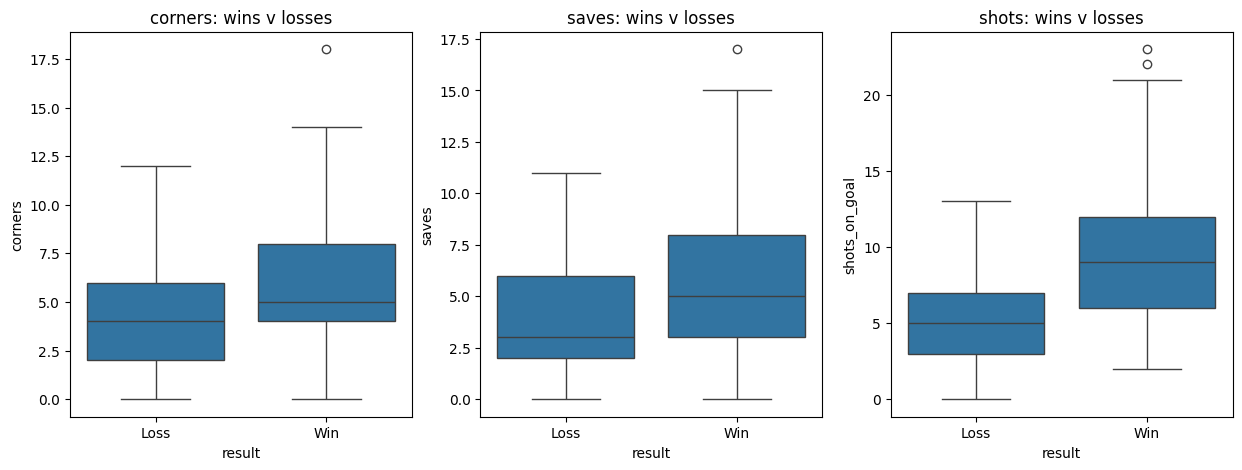

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# create a blank canvas with subplots
# 1 row, 3 columns, figure size 12 wide by 5 tall
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x="result", y="corners", data=df, ax=axes[0])
axes[0].set_title('corners: wins v losses')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Loss', 'Win'])

#saves to wins
sns.boxplot(x="result", y="saves", data=df, ax=axes[1])
axes[1].set_title('saves: wins v losses')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Loss', 'Win'])

#shots to wins
sns.boxplot(x="result", y="shots_on_goal", data=df, ax=axes[2])
axes[2].set_title('shots: wins v losses')
axes[2].set_xticks([0,1])
axes[2].set_xticklabels(['Loss', 'Win'])

# show the plot
plt.show()

<Axes: >

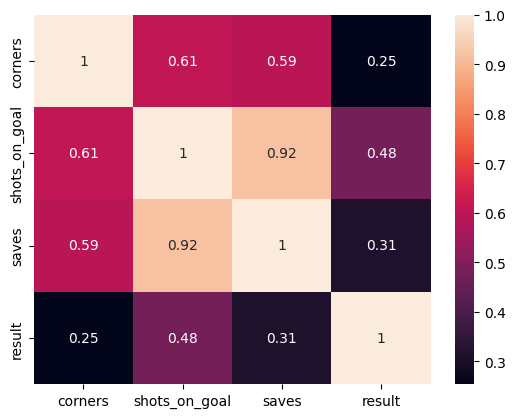

In [6]:
sns.heatmap(df[['corners', 'shots_on_goal', 'saves', 'result']].corr(), annot=True)

## EDA Findings

The correlation heatmap reveals that shots on goal(sog) is the strongest predictor of winning with a correlation of 0.48, followed by saves (0.31) and corners (0.25). 

Shots on goal and saves have a 0.92 correlation with each other. This makes sense because shots on goal measure Cal's offensive output while saves measure how much defensive pressure Cal is under.
In more evenly matched, high-intensity games, both Cal and the opposing team will tend to be more active, driving both stats up simultaneously.

Corners showed the weakest relationship with winning, suggesting that creating scoring opportunities through shots in regular game play matters more.

## Model Building
Training Logistic Regression and Decision Tree classifiers

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/Users/adya/Desktop/cal_fh_data.csv')


# define features and target
X = df[['corners', 'shots_on_goal', 'saves']]
y = df['result']

# split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training games:", len(X_train))
print("Testing games:", len(X_test))

Training games: 148
Testing games: 38


In [8]:
# training the model
from sklearn.linear_model import LogisticRegression
linear_model =  LogisticRegression()
linear_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [9]:
#testing the model 
from sklearn.metrics import accuracy_score
prediction_y = linear_model.predict(X_test)
print(accuracy_score(prediction_y, y_test))
#accuracy score is the percent of predictions the model got right

0.7105263157894737


In [10]:
from sklearn.tree import DecisionTreeClassifier
descion_tree = DecisionTreeClassifier(max_depth=3)
descion_tree.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [11]:
#testing the model 
prediction_y_tree = descion_tree.predict(X_test)
print(accuracy_score(prediction_y_tree, y_test))



0.6052631578947368


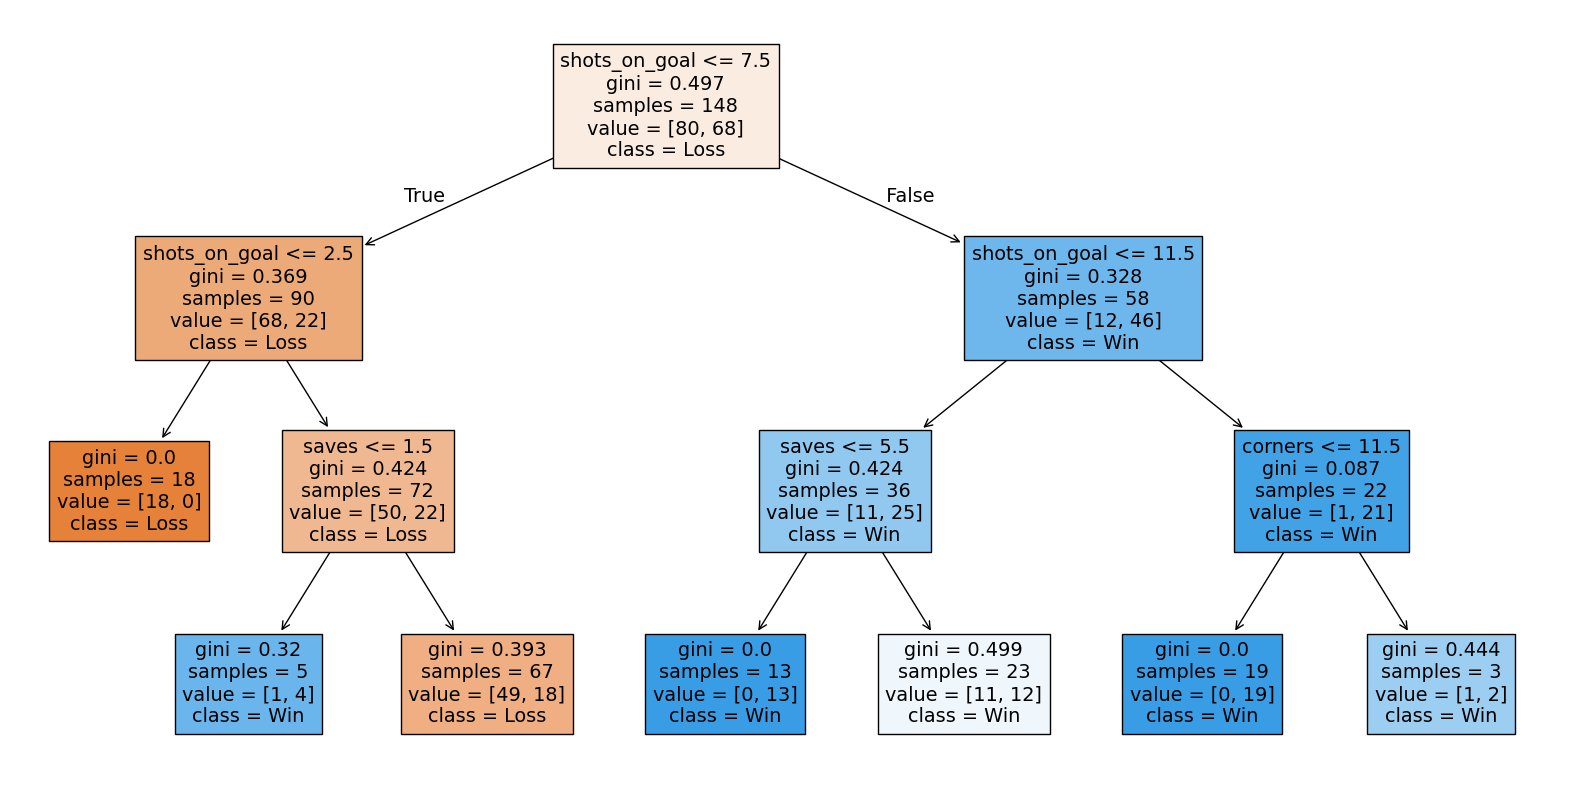

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(descion_tree, feature_names=['corners', 'shots_on_goal', 'saves'], class_names=['Loss', 'Win'], filled=True)
plt.show()

## Evaluation

Rule 1 — Shots on Goal first:

If SOG ≤ 7.5 → likely Loss (90 games, mostly losses)
If SOG > 7.5 → likely Win (58 games, mostly wins)

Rule 2 — If SOG ≤ 7.5:

If SOG ≤ 2.5 → Loss (18 out of 18, perfect!)
If SOG > 2.5 but saves ≤ 1.5 → mostly Loss
If SOG > 2.5 and saves > 1.5 → still mostly Loss

Rule 3 — If SOG > 7.5:

If saves ≤ 5.5 → Win (13 out of 13, perfect!)
If saves > 5.5 and corners ≤ 11.5 → Win (19 out of 19, perfect!)

True Negative — model predicted Loss, it was actually a Loss ✅
True Positive — model predicted Win, it was actually a Win ✅
False Positive — model predicted Win, it was actually a Loss ❌
False Negative — model predicted Loss, it was actually a Win ❌


In [13]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction_y)

[[18  4]
 [ 7  9]]
38


<Axes: >

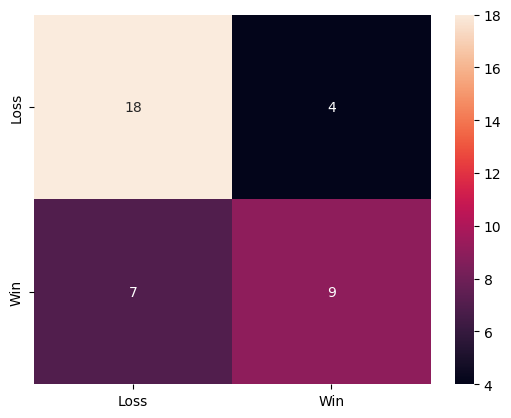

In [14]:
sns.heatmap(data=cm, xticklabels=['Loss', 'Win'], yticklabels=['Loss', 'Win'],  annot=True, fmt='d')

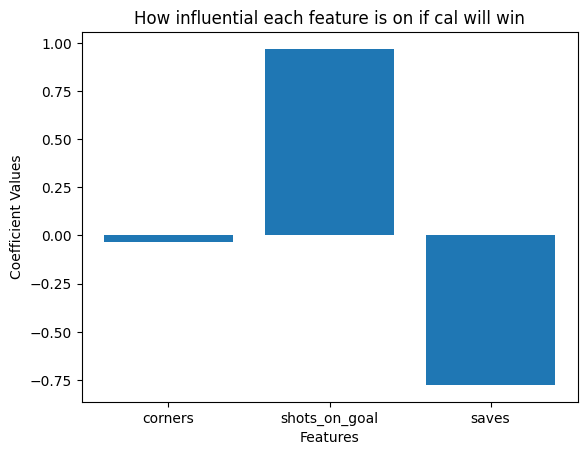

In [15]:
# bar graph
features = ['corners', 'shots_on_goal', 'saves']
coefficients = linear_model.coef_[0]
plt.bar(features, coefficients)
plt.xlabel('Features')
plt.ylabel('Coefficient Values')
plt.title('How influential each feature is on if cal will win')
plt.show()



This data analysis has shown that the most important factor when understanding when cal will win is SOG( shots on goal), having at least 8 shots on goal is a heavy indicator that Cal will win the game, the next important part is keeping our opponents SOG low, which in turn means keeping our saves down. Corners have little effect. 

## Model Application & Predictions

### Win Probability Predictor
Given in-game stats, what is Cal's probability of winning?

In [41]:
#take in stats and predict cal's win probability
def cal_win_probability():
    corners = int(input("How many corners did Cal have?"))
    sog = int(input("How many shots on goal did Cal have?"))
    saves = int(input("How many saves did Cal have?"))
    raw_prob = linear_model.predict_proba([[corners, sog, saves]])
    percent_win = raw_prob[0][1]
    return f"Cal is {percent_win:.1%} likely to win, based on the stats you have inputted and their historical data."
cal_win_probability()


How many corners did Cal have? 2
How many shots on goal did Cal have? 22
How many saves did Cal have? 10


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


'Cal is 100.0% likely to win, based on the stats you have inputted and their historical data.'

In [18]:
# finding the optimal sog

def unrealistic_best_stats_to_win():
    max_sog = df['shots_on_goal'].max()
    max_saves = df['saves'].max()
    max_corners = df['corners'].max()
    best_prob = 0
    optimal_corners = 0
    optimal_sog = 0
    optimal_saves = 0
    for sog in range(1, max_sog):
        for saves in range(1, max_saves):
            for corners in range(1, max_corners):
                current_prob = linear_model.predict_proba([[corners, sog, saves]])[0][1]
                if current_prob > best_prob:
                    optimal_corners = corners
                    optimal_sog = sog
                    optimal_saves = saves
                    best_prob = current_prob
    return f"The unrealistic but best stats that give Cal the best chance of winning are when Cal has {optimal_corners} corners, {optimal_sog} shots on goal, and {optimal_saves} saves. These stats give them a  {best_prob:.1%} chance of winning."
            


In [19]:
unrealistic_best_stats_to_win()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.1

'The unrealistic but best stats that give Cal the best chance of winning are when Cal has 1 corners, 22 shots on goal, and 1 saves. These stats give them a  100.0% chance of winning.'

In [21]:
def stats_for_90_percent():
    results = []
    for sog in range(1, 15):
        for saves in range(1, 10):
            for corners in range(1, 12):
                current_prob = linear_model.predict_proba([[corners, sog, saves]])[0][1]
                if current_prob >= 0.9:
                    results.append([corners, sog, saves])
    return results
print(stats_for_90_percent())

[[1, 7, 1], [2, 7, 1], [3, 7, 1], [4, 7, 1], [5, 7, 1], [6, 7, 1], [7, 7, 1], [8, 7, 1], [9, 7, 1], [10, 7, 1], [11, 7, 1], [1, 7, 2], [1, 8, 1], [2, 8, 1], [3, 8, 1], [4, 8, 1], [5, 8, 1], [6, 8, 1], [7, 8, 1], [8, 8, 1], [9, 8, 1], [10, 8, 1], [11, 8, 1], [1, 8, 2], [2, 8, 2], [3, 8, 2], [4, 8, 2], [5, 8, 2], [6, 8, 2], [7, 8, 2], [8, 8, 2], [9, 8, 2], [10, 8, 2], [11, 8, 2], [1, 8, 3], [2, 8, 3], [3, 8, 3], [4, 8, 3], [5, 8, 3], [6, 8, 3], [7, 8, 3], [1, 9, 1], [2, 9, 1], [3, 9, 1], [4, 9, 1], [5, 9, 1], [6, 9, 1], [7, 9, 1], [8, 9, 1], [9, 9, 1], [10, 9, 1], [11, 9, 1], [1, 9, 2], [2, 9, 2], [3, 9, 2], [4, 9, 2], [5, 9, 2], [6, 9, 2], [7, 9, 2], [8, 9, 2], [9, 9, 2], [10, 9, 2], [11, 9, 2], [1, 9, 3], [2, 9, 3], [3, 9, 3], [4, 9, 3], [5, 9, 3], [6, 9, 3], [7, 9, 3], [8, 9, 3], [9, 9, 3], [10, 9, 3], [11, 9, 3], [1, 9, 4], [2, 9, 4], [3, 9, 4], [4, 9, 4], [5, 9, 4], [6, 9, 4], [7, 9, 4], [8, 9, 4], [9, 9, 4], [10, 9, 4], [11, 9, 4], [1, 10, 1], [2, 10, 1], [3, 10, 1], [4, 10, 1], [5

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.1

In [35]:
#depending on saves
def stats_for_90_percent_based_on_saves():
    for saves in range(1, 10):
        for sog in range(1, 15):
            current_prob = linear_model.predict_proba([[df['corners'].mean(), sog, saves]])[0][1]
            if current_prob >= 0.90:
                print(f"With {saves} saves, Cal needs {sog} SOG to hit 90% win probability")
                break

stats_for_90_percent_based_on_saves()

With 1 saves, Cal needs 7 SOG to hit 90% win probability
With 2 saves, Cal needs 8 SOG to hit 90% win probability
With 3 saves, Cal needs 8 SOG to hit 90% win probability
With 4 saves, Cal needs 9 SOG to hit 90% win probability
With 5 saves, Cal needs 10 SOG to hit 90% win probability
With 6 saves, Cal needs 11 SOG to hit 90% win probability
With 7 saves, Cal needs 12 SOG to hit 90% win probability
With 8 saves, Cal needs 12 SOG to hit 90% win probability
With 9 saves, Cal needs 13 SOG to hit 90% win probability


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.1

## Conclusion


Through the data analysis and models, especially the confusion matrix, I was able to discern that the most influential stat to determine if Cal wins or loses is shots on goal. 


### Model Application

Using the linear regression model I have made, I have built a function to determine whether Cal will win or lose based on stats that the user can input, in order to aid the coaching staff in finding quantitative stats to reach for and rely on. 

It is integral to remember that these stats are just the quantitative side to the game; there are many other factors that come into play, but with having a set of stats in mind, Cal players and the team are able to control their controlables and fight to maximize their odds of winning. 

I have also included another function which places corners, at their average, which is around 5. Using this data, based on the number of saves Cal has, the number of shots on goal shifts, helping the coaching staff shift their stat goals as the game goes on. 

I hope that this model can be used to help our team grow stronger and build concrete goals to chase after each game!